In [1]:
# Detecting compatibility of scipy and quimb versions
import scipy
import quimb
print(scipy.__version__)
print(quimb.__version__)

%config InlineBackend.figure_formats = ['svg']

import random
import quimb as qu
import quimb.tensor as qtn

1.15.2
1.11.2


In [ ]:
# 20 qubits and tag the initial wavefunction tensors
N = 20
J = 0.5     # 相互作用强度
h = 1.0     # 横场强度
t = 1     # 演化时间
r = 10   # trotter步数

z_angle = - J * t / r
x_angle = - h * t / r

circ = qtn.Circuit(N)

# initial layer of hadamards
for i in range(N):
    circ.apply_gate('RX', x_angle, i, gate_round=0)

# 8 rounds of entangling gates
for j in range(1, r+1):

    # ZZ rotations on even pairs
    for i in range(0, N-1, 2):
        circ.apply_gate('CX', i, i + 1, gate_round=j)
        circ.apply_gate('RZ', 2 * z_angle, i+1, gate_round=j)
        circ.apply_gate('CX', i, i + 1, gate_round=j)
        
    # ZZ rotations odd pairs
    for i in range(1, N-1, 2):
        circ.apply_gate('CX', i, i + 1, gate_round=j)
        circ.apply_gate('RZ', 2 * z_angle, i+1, gate_round=j)
        circ.apply_gate('CX', i, i + 1, gate_round=j)

    # X rotations
    if j < r:
        for i in range(N):
            circ.apply_gate('RX', 2 * x_angle, i, gate_round=j)
    else:
        for i in range(N):
            circ.apply_gate('RX', x_angle, i, gate_round=j+1)


circ

<Circuit(n=20, num_gates=790, gate_opts={'contract': 'auto-split-gate', 'propagate_tags': 'register'})>

In [5]:
for g in circ.gates:
    print(g)

<Gate(label=RX, params=[-0.1], qubits=(0,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(1,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(2,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(3,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(4,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(5,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(6,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(7,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(8,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(9,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(10,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(11,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(12,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(13,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(14,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(15,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(16,), round=0)>
<Gate(label=RX, params=[-0.1], qubits=(17,), round=0)>
<Gate(label=RX, para

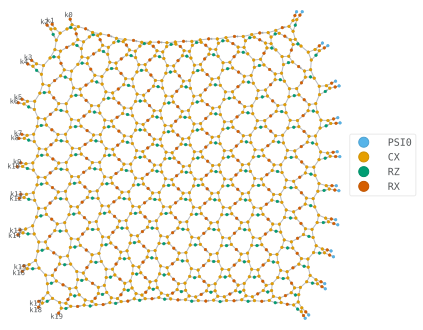

In [28]:
# circ.psi.draw(color=['PSI0', 'H', 'CX', 'RZ', 'RX', 'CZ'])
circ.psi.draw(color=['PSI0', 'CX', 'RZ', 'RX'])

In [29]:
%%time
# sample it 8 times
for b in circ.sample(8, seed=43):
    print(b)

11011111100000011100
00000101111111100000
11001110110111000011
11101111011001000111
10011111011100001111
11111111011111110110
01111100110111111110
10011111100000000001
CPU times: user 12.8 s, sys: 113 ms, total: 12.9 s
Wall time: 12.8 s


In [ ]:
# Read `r_1_noise_8_seed_43.json` and compute parity per sample
from pathlib import Path
import json
from collections import Counter
import matplotlib.pyplot as plt

p = Path("sample_results_N_30/r_1_noise_1_seed_43.json")
if not p.exists():
    raise FileNotFoundError(p)

text = p.read_text(encoding="utf-8").strip()
if not text:
    strs = []
else:
    # 先尝试把整个文件当作一个 JSON array 读入
    try:
        obj = json.loads(text)
        if isinstance(obj, list):
            # 如果是 list，确保元素为字符串（或转为字符串）
            strs = [str(x) for x in obj]
        else:
            # 不是 list 则回退到逐行解析
            raise ValueError("not-a-list")
    except (json.JSONDecodeError, ValueError):
        strs = []
        for line in text.splitlines():
            s = line.strip()
            if not s:
                continue
            try:
                v = json.loads(s)
                # 如果每行是 JSON 字符串 / 数组 / 对象，尽量抽出字符串表示
                if isinstance(v, str):
                    strs.append(v)
                elif isinstance(v, list):
                    strs.extend(str(x) for x in v)
                else:
                    strs.append(str(v))
            except json.JSONDecodeError:
                # 裸 bitstring 行，直接当作字符串
                strs.append(s)

samples = strs

def sum_Z(bitstring):
    return sum((1 - 2 * int(b) ) for b in bitstring)

observable = 0
for sample in samples:
    observable += sum_Z(sample) / len(samples)
    
print('Estimated <sum Z> = ', observable)

In [ ]:
# 10 qubits and tag the initial wavefunction tensors
circ = qtn.Circuit(N=10)

# initial layer of hadamards
for i in range(10):
    circ.apply_gate('H', i, gate_round=0)

# 8 rounds of entangling gates
for r in range(1, 9):

    # even pairs
    for i in range(0, 10, 2):
        circ.apply_gate('CX', i, i + 1, gate_round=r)

    # Y-rotations
    for i in range(10):
        circ.apply_gate('RZ', 1.234, i, gate_round=r)

    # odd pairs
    for i in range(1, 9, 2):
        circ.apply_gate('CZ', i, i + 1, gate_round=r)

    # X-rotations
    for i in range(10):
        circ.apply_gate('RX', 1.234, i, gate_round=r)

# final layer of hadamards
for i in range(10):
    circ.apply_gate('H', i, gate_round=r + 1)

circ

In [ ]:
circ = qtn.Circuit(N=1)

circ.apply_gate('H', 0)
circ.apply_gate('H', 0)
circ.apply_gate('H', 0)
circ.apply_gate('H', 0)
# circ.apply_gate('H', 0)

# sample it a few times and count frequencies
from collections import Counter

samples = list(circ.sample(10000, seed=42))
counts = Counter(samples)

print('Counts (most common first):')
for outcome, cnt in counts.most_common():
    print(f"{outcome}: {cnt}")

print('\nProbabilities:')
total = sum(counts.values())
for outcome, cnt in counts.most_common():
    print(f"{outcome}: {cnt/total:.4f}")

In [ ]:
# circ.psi.draw(color=['PSI0', 'H', 'CX', 'RZ', 'RX', 'CZ'])
circ.psi.draw(color=['PSI0', 'CX', 'RZ', 'RX','H'])

for g in circ.gates:
    print(g)

In [ ]:
# circ.psi.draw(color=['PSI0', 'H', 'CX', 'RZ', 'RX', 'CZ'])
circ.psi.draw(color=['PSI0', 'CX', 'X', 'RX','H'])
for g in circ.gates:
    print(g)